# 第1章 金融与量化

> 小林有1万元，计划投资一年。他可以选择活期存款、一年期国债、某公司股票，或沪深300 ETF。

**三条学习线**

- 金融：储蓄者、融资者、现金、债券、股票、基金、收益和风险。
- 数学：现金流、简单收益率、情景和期望的直觉。
- Python：字典、DataFrame、函数、条件、随机数组、图表和动画。

**完成标准**

1. 能用自己的话区分股票和债券；
2. 能画出简单现金流时间轴；
3. 能计算持有期收益率；
4. 能解释“期望终值相近”为什么不等于“风险相同”；
5. 能修改模拟假设并记录结论。



## AI学习状态

当前进度：第1章开始

已掌握：第0章的变量、循环、函数和NumPy基础（需根据实际情况修改）

仍然薄弱：待填写

常见错误：待填写

下一步：先回答情境问题，再运行模型。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(20260711)
print("实验随机种子：20260711")

## 1.1 金融首先是“跨时间交换资源”

有些人今天有暂时不用的钱，有些人今天需要钱来读书、买房、建设工厂或修建公共设施。金融系统帮助资金从**盈余方**流向**资金需求方**，同时约定未来的权利、义务和风险。

一个最小金融系统包含：

| 角色 | 今天 | 未来 | 主要问题 |
|---|---|---|---|
| 储蓄者/投资者 | 提供资金 | 希望收回本金并获得回报 | 会不会亏？何时能取回？ |
| 企业/政府/个人融资者 | 获得资金 | 偿还债务或分享企业成果 | 资金成本是多少？ |
| 银行、交易所、基金等中介 | 连接双方、提供交易与管理 | 收取费用并承担相应责任 | 如何控制信用、流动性和操作风险？ |


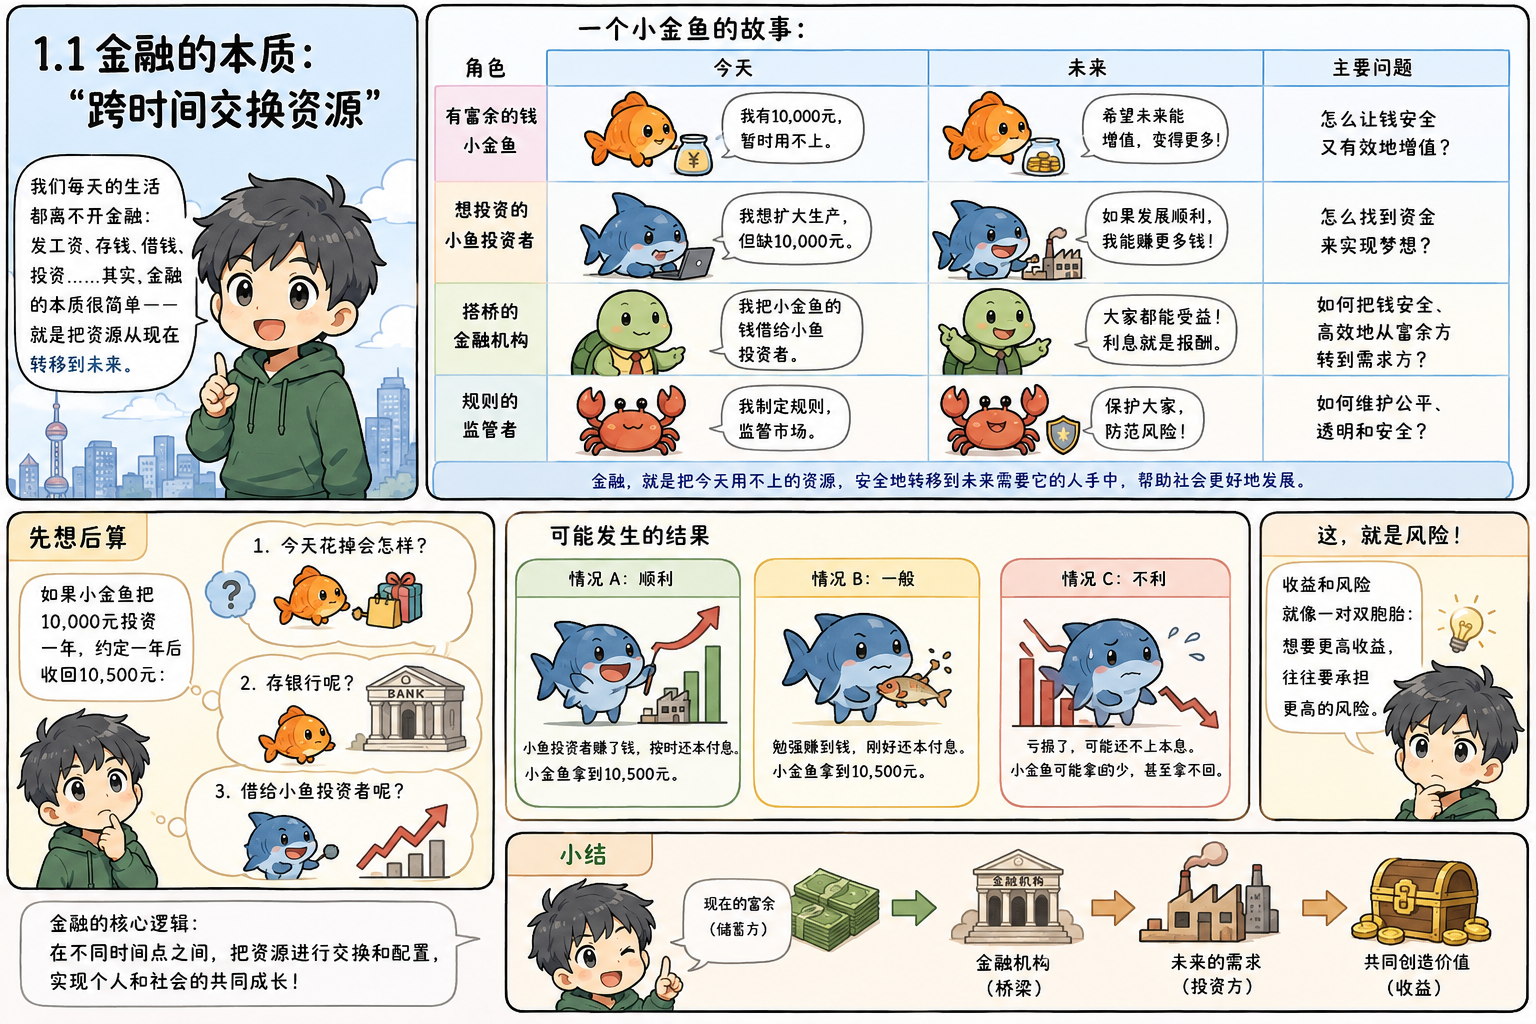
### 先想后算

如果小林把10,000元借给同学一年，约定一年后收回10,500元：

1. 今天谁是资金提供者？
2. 未来的10,500元中，哪部分是本金，哪部分是回报？
3. 如果同学无法偿还，这属于什么直观风险？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.2 用现金流时间轴描述承诺

站在小林的角度，今天付出10,000元记为负现金流，一年后收到10,500元记为正现金流：

$$CF_0=-10{,}000,\qquad CF_1=+10{,}500$$

正负号取决于**观察者视角**。站在借款人角度，符号正好相反。

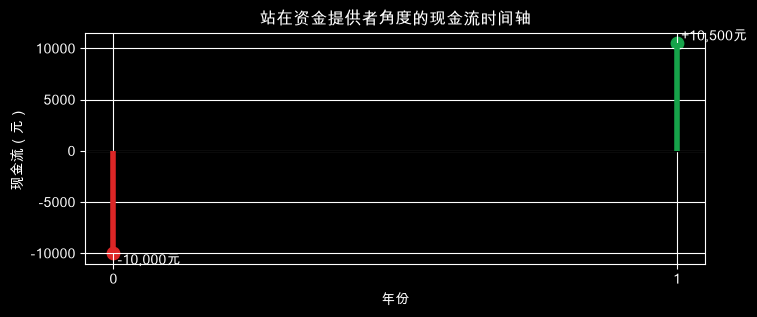

{0: -10000, 1: 10500}


In [54]:
cash_flows = {0: -10_000, 1: 10_500}

fig, ax = plt.subplots(figsize=(8, 3))
ax.axhline(0, color="black", linewidth=1)
for time, amount in cash_flows.items():
    color = "#16a34a" if amount > 0 else "#dc2626"
    ax.vlines(time, 0, amount, color=color, linewidth=4)
    ax.scatter(time, amount, color=color, s=80)
    ax.text(time, amount, f" {amount:+,.0f}元", va="bottom" if amount > 0 else "top")

ax.set(title="站在资金提供者角度的现金流时间轴", xlabel="年份", ylabel="现金流（元）")
ax.set_xticks([0, 1])
plt.show()
print(cash_flows)

**Python提示：字典**

`{0: -10000, 1: 10500}`用“键:值”保存数据。这里键是时间，值是该时点现金流。字典适合表达少量有明确标签的项目；以后大量时间序列会使用pandas。

**量化编程警告：先确定视角和符号**

同一笔交易在双方账上符号相反。如果不写清视角，净现值、盈亏和风险计算都会混乱。

## 1.3 第一个收益率

买入价格为 $P_0$，卖出价值为 $P_1$，期间暂不考虑其他现金流，则持有期简单收益率为：

$$R=\frac{P_1-P_0}{P_0}=\frac{P_1}{P_0}-1$$

它回答的是：**相对于最初投入，财富变化了多大比例？**

In [55]:
initial_value = 10_000
final_value = 10_500
holding_return = final_value / initial_value - 1

print(f"绝对增加：{final_value - initial_value:.2f}元")
print(f"持有期收益率：{holding_return:.2%}")

绝对增加：500.00元
持有期收益率：5.00%


### 手算检查

如果初始投入改为20,000元、最终价值为21,000元：绝对增加变成多少？收益率是否改变？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.4 四类常见选择：现金、债券、股票、基金

### 现金或存款类工具

主要作用是支付、保存流动性和满足近期支出。它并非“完全没有风险”：购买力可能被通胀侵蚀，不同账户也有不同信用、期限和规则。

### 债券

债券本质上是债务证券。投资者把钱借给政府、企业等发行者，发行者约定支付利息并在到期时偿还本金。主要风险包括利率、信用和流动性风险。

### 股票

股票代表企业所有权的一部分。回报可能来自股息和价格上涨，但没有固定偿还承诺；企业经营和市场估值都会影响结果。

### 基金

基金把许多投资者的资金汇集起来，持有股票、债券或其他资产。基金是一种组织与持有方式，不自动等于低风险；风险取决于底层资产、策略、费用和约束。

**来源提示**：以上入门定义可对照 Investor.gov 的 Stocks、Bonds 和 Mutual Funds 页面。中国市场的具体规则将在后续章节改用中国证监会、交易所和基金业协会资料核实。

In [56]:
products = pd.DataFrame(
    {
        "核心关系": ["持有可支付资产", "把钱借给发行者", "拥有企业的一部分", "共同持有一篮子资产"],
        "典型现金流": ["取用本金/利息", "利息与本金偿还", "股息与出售价值", "分配收益与份额赎回/交易价值"],
        "主要不确定性": ["通胀、规则、信用", "利率、信用、流动性", "经营、估值、市场", "取决于底层资产、费用和策略"],
    },
    index=["现金/存款类", "债券", "股票", "基金"],
)
products

,核心关系,典型现金流,主要不确定性
现金/存款类,持有可支付资产,取用本金/利息,通胀、规则、信用
债券,把钱借给发行者,利息与本金偿还,利率、信用、流动性
股票,拥有企业的一部分,股息与出售价值,经营、估值、市场
基金,共同持有一篮子资产,分配收益与份额赎回/交易价值,取决于底层资产、费用和策略


### 判断练习

下面说法是否正确？请先写理由，再让AI检查。

1. 买入企业债券后，投资者成为企业所有者。
2. 股票价格上涨是股票投资者唯一可能的回报来源。
3. 基金一定比单只股票安全。
4. 现金没有任何风险。

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.5 什么是量化分析？

“量化”不是“用复杂模型猜涨跌”。一个完整的量化问题至少包含：

1. **问题**：要比较、解释、预测还是决策？
2. **变量**：价格、现金流、收益率、期限、风险分别如何定义？
3. **假设**：哪些条件被简化或固定？
4. **数据**：数据何时可知、来源和单位是什么？
5. **模型**：变量如何联系？
6. **验证**：手算、边界条件、样本外结果是否支持结论？
7. **决策边界**：交易成本、约束和模型失效如何处理？

本章的模型很简单，但已经必须遵守这七步。

## 1.6 情景不是预测：先建立一个两状态模型

假设某项投资一年后只有两个教学情景：

- 较好情景：10,000元变成12,000元；
- 较差情景：10,000元变成8,000元。

假设两个情景各占50%。这不是对真实股票的预测，只是用最小模型理解“平均结果”和“结果分散”。

In [57]:
scenario_values = np.array([12_000, 8_000])
probabilities = np.array([0.5, 0.5])

expected_value = np.sum(scenario_values * probabilities)
scenario_returns = scenario_values / 10_000 - 1

print("情景终值：", scenario_values)
print("情景收益率：", scenario_returns)
print("期望终值：", expected_value)
print("期望不等于必然发生：", expected_value not in scenario_values)

情景终值： [12000  8000]
情景收益率： [ 0.2 -0.2]
期望终值： 10000.0
期望不等于必然发生： True


期望终值为

$$E[W_1]=\sum_i p_iW_i$$

这里期望恰好等于10,000元，但实际情景中没有一个结果等于10,000元。

### 观察问题

1. “期望没有亏损”能否推出“这一年不会亏损”？
2. 如果较差情景改为2,000元，期望和风险分别如何变化？
3. 这个模型遗漏了真实市场中的哪些可能性？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.7 从两个情景扩展到许多随机路径

我们构造三种纯教学资产：

- “现金类”：年收益波动很小；
- “债券类”：平均收益和波动居中；
- “股票类”：平均收益假设较高，但波动明显更大。

为保持初学者可读性，本章暂用正态分布生成年收益。真实金融收益可能厚尾、偏斜并随时间变化，第7章会专门修正这一简化。

In [58]:
assumptions = pd.DataFrame(
    {
        "mean_return": [0.02, 0.04, 0.07],
        "volatility": [0.005, 0.06, 0.18],
    },
    index=["现金类", "债券类", "股票类"],
)
assumptions.style.format("{:.1%}")

,mean_return,volatility
现金类,2.0%,0.5%
债券类,4.0%,6.0%
股票类,7.0%,18.0%


**量化编程警告：参数是模型输入，不是事实**

上表数值是为了观察差异而设置的教学假设。严谨研究必须说明估计区间、数据来源、样本时期和不确定性，不能把历史均值直接当成未来承诺。

In [59]:
def simulate_wealth(initial, mean_return, volatility, years, paths, rng):
    # 用独立正态年收益生成教学性财富路径。
    returns = rng.normal(mean_return, volatility, size=(years, paths))
    wealth = np.empty((years + 1, paths))
    wealth[0] = initial
    wealth[1:] = initial * np.cumprod(1 + returns, axis=0)
    return wealth, returns


simulation_rng = np.random.default_rng(42)
simulated = {}
for asset, row in assumptions.iterrows():
    wealth, returns = simulate_wealth(
        initial=10_000,
        mean_return=row["mean_return"],
        volatility=row["volatility"],
        years=10,
        paths=2_000,
        rng=simulation_rng,
    )
    simulated[asset] = {"wealth": wealth, "returns": returns}

print({name: value["wealth"].shape for name, value in simulated.items()})

{'现金类': (11, 2000), '债券类': (11, 2000), '股票类': (11, 2000)}


**Python提示：二维数组与`axis`**

`returns`形状是`(年份, 路径)`。`np.cumprod(..., axis=0)`沿年份方向累计，使每一列成为一条财富路径。量化代码中必须先写清每个轴代表什么。

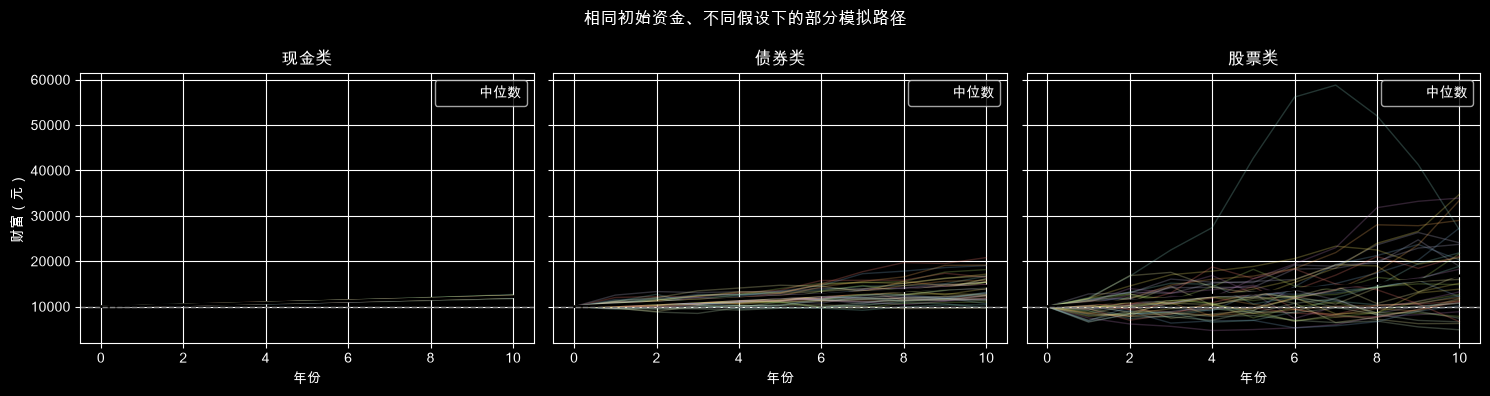

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (asset, result) in zip(axes, simulated.items()):
    wealth = result["wealth"]
    ax.plot(wealth[:, :40], alpha=0.25, linewidth=1)
    ax.plot(np.median(wealth, axis=1), color="black", linewidth=2, label="中位数")
    ax.axhline(10_000, color="gray", linestyle="--", linewidth=1)
    ax.set(title=asset, xlabel="年份")
    ax.legend()

axes[0].set_ylabel("财富（元）")
fig.suptitle("相同初始资金、不同假设下的部分模拟路径")
plt.tight_layout()
plt.show()

### 观察问题

1. 哪类资产的路径最集中？哪类最分散？
2. 股票类的平均收益假设较高，是否意味着每条股票路径都优于现金？
3. 为什么图中只画40条路径，而统计时保留2000条？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

In [61]:
summary_rows = []
for asset, result in simulated.items():
    terminal = result["wealth"][-1]
    summary_rows.append(
        {
            "资产": asset,
            "平均终值": terminal.mean(),
            "中位终值": np.median(terminal),
            "10%分位": np.quantile(terminal, 0.10),
            "90%分位": np.quantile(terminal, 0.90),
            "低于本金的比例": np.mean(terminal < 10_000),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("资产")
display(summary.style.format({
    "平均终值": "{:,.0f}",
    "中位终值": "{:,.0f}",
    "10%分位": "{:,.0f}",
    "90%分位": "{:,.0f}",
    "低于本金的比例": "{:.1%}",
}))

,平均终值,中位终值,10%分位,90%分位,低于本金的比例
资产,,,,,
现金类,"12,193","12,191","11,954","12,433",0.0%
债券类,"14,819","14,506","11,611","18,286",1.3%
股票类,"19,137","16,770","8,337","33,133",17.6%


### 从图到证据

路径图帮助建立直觉，汇总表帮助精确比较。请用表中至少两个指标说明“高平均终值”和“高不确定性”可以同时存在。

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.8 动画：不确定性如何逐年展开

动画只展示股票类的20条路径。播放时观察：早期接近的路径如何随时间逐渐分散。动画下方另有普通文本摘要，便于AI检查。

In [62]:
stock_paths = simulated["股票类"]["wealth"][:, :20]
years_axis = np.arange(stock_paths.shape[0])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set(xlim=(0, years_axis[-1]),
       ylim=(0, stock_paths.max() * 1.05),
       xlabel="年份", ylabel="财富（元）",
       title="股票类教学模型：财富路径逐年展开")
lines = [ax.plot([], [], alpha=0.55)[0] for _ in range(stock_paths.shape[1])]

def update(frame):
    for index, line in enumerate(lines):
        line.set_data(years_axis[: frame + 1], stock_paths[: frame + 1, index])
    return lines

animation = FuncAnimation(fig, update, frames=len(years_axis), interval=350, blit=True)
plt.close(fig)
display(HTML(animation.to_jshtml()))
print({
    "displayed_paths": int(stock_paths.shape[1]),
    "years": int(years_axis[-1]),
    "min_terminal": round(float(stock_paths[-1].min()), 2),
    "max_terminal": round(float(stock_paths[-1].max()), 2),
})

{'displayed_paths': 20, 'years': 10, 'min_terminal': 4886.78, 'max_terminal': 23723.08}


## 1.9 交互实验：修改股票类假设

拖动“平均年收益”和“年波动率”。每次更新都使用同一个随机种子，使差异主要来自参数，而不是重新抽到另一批随机数。

In [63]:
def terminal_distribution(mean_return=0.07, volatility=0.18):
    local_rng = np.random.default_rng(7)
    wealth, _ = simulate_wealth(10_000, mean_return, volatility, 10, 5_000, local_rng)
    terminal = wealth[-1]

    fig, ax = plt.subplots()
    ax.hist(terminal, bins=50, color="#2563eb", alpha=0.75)
    ax.axvline(np.median(terminal), color="black", linewidth=2, label="中位数")
    ax.axvline(10_000, color="#dc2626", linestyle="--", label="初始本金")
    ax.set(title="10年终值分布（教学模型）", xlabel="终值（元）", ylabel="模拟次数")
    ax.legend()
    plt.show()

    print({
        "mean_return": mean_return,
        "volatility": volatility,
        "median_terminal": round(float(np.median(terminal)), 2),
        "loss_probability": round(float(np.mean(terminal < 10_000)), 4),
    })


try:
    from ipywidgets import interact, FloatSlider
    interact(
        terminal_distribution,
        mean_return=FloatSlider(value=0.07, min=-0.05, max=0.15, step=0.01, description="平均收益"),
        volatility=FloatSlider(value=0.18, min=0.01, max=0.50, step=0.01, description="波动率"),
    )
except ImportError:
    print("未安装ipywidgets：请执行 python -m pip install ipywidgets")
    terminal_distribution()

interactive(children=(FloatSlider(value=0.07, description='平均收益', max=0.15, min=-0.05, step=0.01), FloatSlider…

### 参数实验记录

至少尝试三组参数，并记录“中位终值”和“低于本金的比例”。不要把模拟概率解释成真实世界概率。

| 平均收益假设 | 波动率假设 | 中位终值 | 低于本金的比例 | 我的解释 |
|---:|---:|---:|---:|---|
| | | | | |
| | | | | |
| | | | | |

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 1.10 Python练习：比较一个自定义情景

请完成函数，使它接收初始金额和一组可能终值，返回每个情景的收益率。先手算`[9000, 10000, 11000]`相对于10000元的结果。

In [64]:
def scenario_returns(initial, final_values):
    # 返回每个终值相对于initial的简单收益率数组。
    # TODO：把final_values转换为NumPy数组并计算收益率
    return None

In [65]:
result = scenario_returns(10_000, [9_000, 10_000, 11_000])
if result is None:
    print("练习尚未完成。")
else:
    expected = np.array([-0.10, 0.00, 0.10])
    print("你的结果：", result)
    print("基础测试通过：", np.allclose(result, expected))

练习尚未完成。


### AI批改请求

保存Notebook后，可以让Codex检查：

> 请只检查第1.10节。我是否正确处理了列表输入、除法顺序和返回类型？再给我一个`initial=0`的边界问题，但先不要直接提供最终实现。

### 我的修正记录

<!-- 保留第一次错误和修正原因 -->

## 1.11 小型研究任务：给小林一份“不做推荐”的比较报告

从本章的现金、债券、股票和基金概念中任选三类，完成一页观察报告：

1. 每类资产代表什么权利或关系？
2. 可能产生哪些现金流？
3. 至少列出两类风险；
4. 本章模拟使用了哪些明显简化？
5. 为了做真实比较，还需要哪些数据？

不要写“应该买某资产”，也不要把教学参数当成预期收益。

### 我的报告

<!-- 在这里填写；完成前AI不要代答 -->

## 本章压缩总结

- 金融系统连接今天的资金与未来的权利、义务和风险；
- 债券通常代表债权，股票代表所有权，基金代表共同持有的一篮子资产；
- 收益率必须相对于初始投入定义；
- 期望是按概率加权的平均，不是必然发生的结果；
- 模拟用于研究“如果假设成立会怎样”，不是预测或承诺；
- 量化研究必须写清问题、变量、假设、数据、模型、验证和边界；
- Python代码必须同时接受金融逻辑和数值测试。

**参考入口**

- Investor.gov 投资入门：https://www.investor.gov/introduction-investing
- Stocks：https://www.investor.gov/introduction-investing/investing-basics/investment-products/stocks
- Bonds：https://www.investor.gov/introduction-investing/investing-basics/investment-products/bonds-or-fixed-income-products/bonds
- Mutual Funds：https://www.investor.gov/introduction-investing/investing-basics/investment-products/mutual-funds-and-exchange-traded-funds-etfs/mutual-funds
- NumPy随机抽样：https://numpy.org/doc/stable/reference/random/index.html